In [15]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

In [16]:

FS = 10
class MySimulator():
    def __init__(self):
        self._pos = [[0,0],[0,0]]
        self.reset()
        
        self.fig, self.ax = plt.subplots(1, 1, figsize=(6,6))
        self.ax.set_xlim(-0.5,FS-0.5)
        self.ax.set_ylim(-0.5,FS-0.5)
        for i in range(FS+1):
            self.ax.plot((i-0.5,i-0.5),(-0.5,FS-0.5),color='lightgrey', linewidth=0.5)
        for i in range(FS+1):
            self.ax.plot((-0.5,FS-0.5),(i-0.5,i-0.5),color='lightgrey', linewidth=0.5)
        self.ims = []
#初期化
    def reset(self):
        self._pos = [[2,2],[4,4]]
#行動による状態変化
    def get_state(self, n0, n1, r):
        done = False
        x0, y0 = self._pos[n0][0], self._pos[n0][1]
        x1, y1 = self._pos[n1][0], self._pos[n1][1]

        if x0==x1 and y0==y1:
            done = True
            state = int((r-1)**2)
            return state, done
        xr = r
        rw = (r-1)/2
        if (x0 - rw <= x1 <= x0 + rw):
            xr = x1-x0+rw
        elif (x0 - rw <= x1+FS <= x0 + rw):
            xr = x1+FS-x0+rw
        elif (x0 - rw <= x1-FS <= x0 + rw):
            xr = x1-FS-x0+rw
        yr = r
        if (y0 - rw <= y1 <= y0 + rw):
            yr = y1-y0+rw
        elif (y0 - rw <= y1+FS <= y0 + rw):
            yr = y1+FS-y0+rw
        elif (y0 - rw <= y1-FS <= y0 + rw):
            yr = y1-FS-y0+rw
        
        if xr<r and yr<r:
            state = xr+yr*r
        else:
            state = r*r
        return int(state), done
    def step(self, action, turn):
        done = False
        rewards = [0,0]
        if turn==0:
            tbl = [[-1, 0], [0, -1], [1, 0], [0, 1]]
        else:
            tbl = [[-1, 0], [-1,-1],[0, -1], [1,-1],[1, 0], [1,1],[0, 1],[-1,1]]
        x,y = self._pos[turn][0]+tbl[action][0],self._pos[turn][1]+tbl[action][1]
        
        if x==FS:x=0
        if y==FS:y=0
        if x==-1:x=FS-1
        if y==-1:y=FS-1
        self._pos[turn] = [x,y]
        
        if turn==0:
            state, done = env.get_state(0,1,3)
        else:
            state, done = env.get_state(1,0,5)
        
        if done == True:
            rewards = [-1,1]
        return state, rewards, done

    def save_position(self):
        im0 = self.ax.plot(self._pos[0][0],self._pos[0][1],marker="s",linestyle="none", ms=10,c="r")
        im1 = self.ax.plot(self._pos[1][0],self._pos[1][1],marker="D",linestyle="none", ms=10,c="b")
        self.ims.append(im0+im1)


In [17]:
class MyQTable():
    def __init__(self, train=True):
        QV0=np.zeros((10,4), dtype=np.float32)
        QV1=np.zeros((26,8), dtype=np.float32)
        self._QVs = [QV0, QV1]
#行動の選択
    def get_action(self, state, epsilon, turn):
        qv= self._QVs[turn]
        s = state
        if epsilon > np.random.uniform(0, 1):#徐々に最適行動のみをとる、ε-greedy法
            if turn==0:
                next_action = np.random.choice(range(4))
            else:
                next_action = np.random.choice(range(8))
        else:
            a = np.where(qv[s]==qv[s].max())[0]
            next_action = np.random.choice(a)
        return next_action
    def update_Qtable(self, act, reward, state, state_old, turn):
        qv= self._QVs[turn]
        s = state
        so = state_old
        alpha = 0.5
        gamma = 0.9
        maxQ = np.max(qv[s])
        qv[so,act] = (1-alpha)*qv[so,act]+alpha*(reward + gamma*maxQ);
        self._QVs[turn] = qv 

[299, 701]


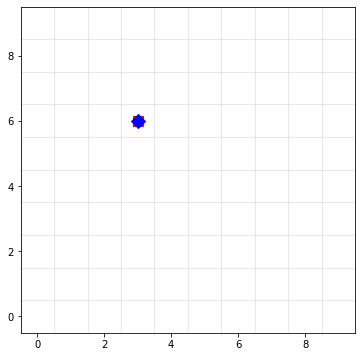

In [18]:
num_episodes = 1000  #総試行回数
num_step = 100
env = MySimulator()
tab = MyQTable()
wins = [0,0]
for episode in range(num_episodes):  #試行数分繰り返す
    env.reset()
    rewards = [0,0]
    epsilon = 0.5 * (1 / (episode + 1))+0.02
    if episode == num_episodes-1:
        env.save_position()
#        epsilon=0
    for step in range(num_step):
        sw, _ = env.get_state(1,0,5)
        aw = tab.get_action(sw, epsilon, 1)
        sw_old = sw
        sw, rewards, done = env.step(aw, 1)
        tab.update_Qtable(aw, rewards[1], sw, sw_old, 1)
        if done == True:
            wins[1] += 1
            tab.update_Qtable(ac, rewards[0], sc, sc_old, 0)
            if episode == num_episodes-1:
                env.save_position()
            break

        if episode == num_episodes-1:
            env.save_position()
        t = 1 
        sc, _ = env.get_state(0,1,3)
        ac = tab.get_action(sc, epsilon, 0)
        sc_old = sc
        sc, rewards, done = env.step(ac, 0)
        tab.update_Qtable(ac, rewards[0], sc, sc_old, 0)
        if done == True:
            wins[1] += 1
            tab.update_Qtable(aw, rewards[1], sw, sw_old, 1)
            if episode == num_episodes-1:
                env.save_position()
            break
        if step== num_step-1:
            wins[0] += 1
        if episode == num_episodes-1:
            env.save_position()
print(wins)

ani = animation.ArtistAnimation(env.fig, env.ims, interval=200, repeat=False)
HTML(ani.to_jshtml())
